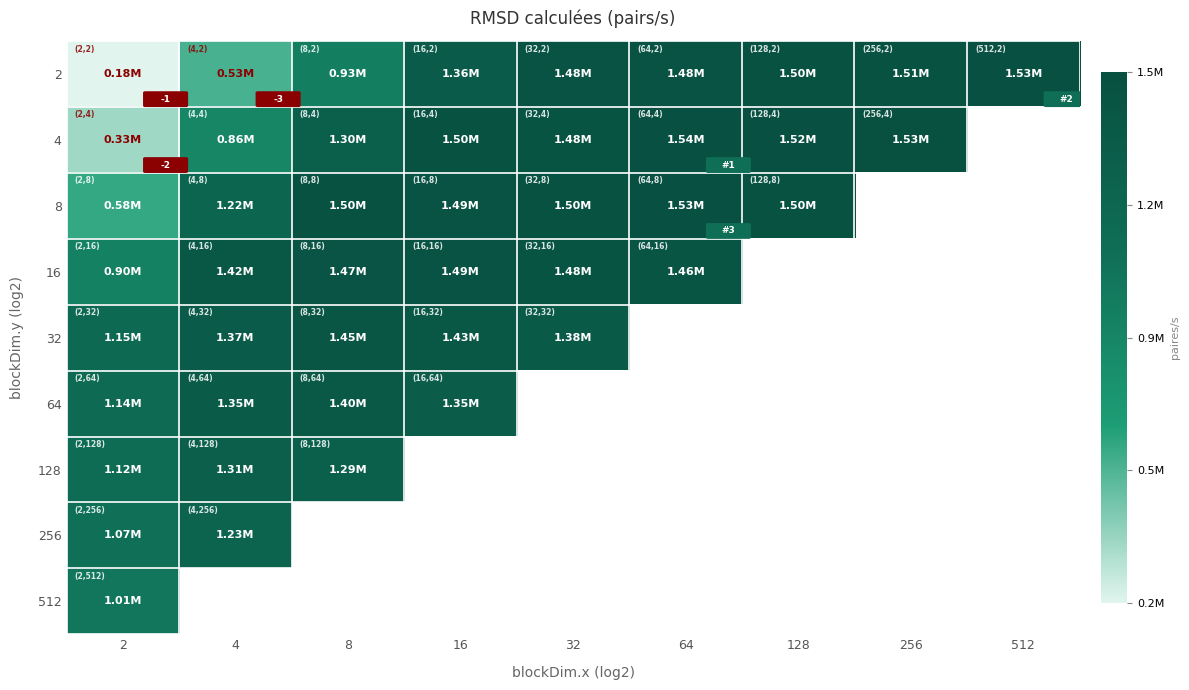

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

# --- Load & compute throughput ---
df = pd.read_csv("Tailles.csv")
df["v"] = (10000 * 9999) / (2 * df["temps"])

xs = sorted(df["x"].unique())
ys = sorted(df["y"].unique())

pivot = df.pivot(index="y", columns="x", values="v")
pivot = pivot.reindex(index=ys, columns=xs)

# --- Top 3 / Bottom 3 ---
ranked = df.sort_values("v", ascending=False).reset_index(drop=True)
top3 = set(zip(ranked.head(3)["x"], ranked.head(3)["y"]))
bot3 = set(zip(ranked.tail(3)["x"], ranked.tail(3)["y"]))

# --- Colormap: light green → dark teal ---
cmap = LinearSegmentedColormap.from_list(
    "teal_ramp", ["#E1F5EE", "#1D9E75", "#0F6E56", "#085041"]
)

# --- Figure ---
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

vmin, vmax = df["v"].min(), df["v"].max()
im = ax.imshow(
    pivot.values,
    aspect="auto",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest",
)

# --- Cell annotations: all cells ---
for yi, y in enumerate(ys):
    for xi, x in enumerate(xs):
        val = pivot.loc[y, x] if (y in pivot.index and x in pivot.columns) else np.nan
        if np.isnan(val):
            continue

        key = (x, y)
        is_top = key in top3
        is_bot = key in bot3

        label_main = f"{val/1e6:.2f}M" if val < 10e6 else f"{val/1e6:.1f}M"
        code_label = f"({x},{y})"

        txt_color  = "#8B0000" if is_bot else "white"
        code_color = "#8B0000" if is_bot else "white"

        # Cell code top-left
        ax.text(xi - 0.43, yi - 0.38, code_label,
                ha="left", va="center", fontsize=5.5, fontweight="bold",
                color=code_color, alpha=0.85)

        # Centered throughput value
        ax.text(xi, yi, label_main,
                ha="center", va="center", fontsize=8, fontweight="bold",
                color=txt_color)

        # Badge for top3 and bot3
        if is_top or is_bot:
            rank_idx = ranked[(ranked["x"] == x) & (ranked["y"] == y)].index[0]
            rank = rank_idx + 1 if is_top else len(ranked) - rank_idx
            badge_txt = f"#{rank}" if is_top else f"-{rank}"
            badge_bg  = "#0F6E56" if is_top else "#8B0000"

            bx = xi + 0.38
            by = yi + 0.38
            ax.add_patch(mpatches.FancyBboxPatch(
                (bx - 0.18, by - 0.10), 0.36, 0.20,
                boxstyle="round,pad=0.02",
                facecolor=badge_bg, edgecolor="none",
                transform=ax.transData, zorder=3,
            ))
            ax.text(bx, by, badge_txt,
                    ha="center", va="center", fontsize=6.5, fontweight="bold",
                    color="#ffffff", zorder=4)

# --- Axes ---
ax.set_xticks(range(len(xs)))
ax.set_yticks(range(len(ys)))
ax.set_xticklabels([str(v) for v in xs], fontsize=9, color="#555")
ax.set_yticklabels([str(v) for v in ys], fontsize=9, color="#555")

ax.set_xlabel("blockDim.x (log2)", fontsize=10, color="#666", labelpad=10)
ax.set_ylabel("blockDim.y (log2)", fontsize=10, color="#666", labelpad=10)
ax.set_title("RMSD calculées (pairs/s)", fontsize=12, fontweight="500", pad=12, color="#333")

for xi in np.arange(-0.5, len(xs), 1):
    ax.axvline(xi, color="white", linewidth=1.2)
for yi in np.arange(-0.5, len(ys), 1):
    ax.axhline(yi, color="white", linewidth=1.2)

ax.tick_params(axis="both", which="both", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# Colorbar
cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.025)
cbar.ax.yaxis.set_tick_params(labelsize=8, color="#888")
cbar.set_label("paires/s", fontsize=8, color="#888")
cbar.outline.set_visible(False)
cbar.set_ticks(np.linspace(vmin, vmax, 5))
cbar.set_ticklabels([f"{v/1e6:.1f}M" for v in np.linspace(vmin, vmax, 5)])

plt.tight_layout()
plt.show()

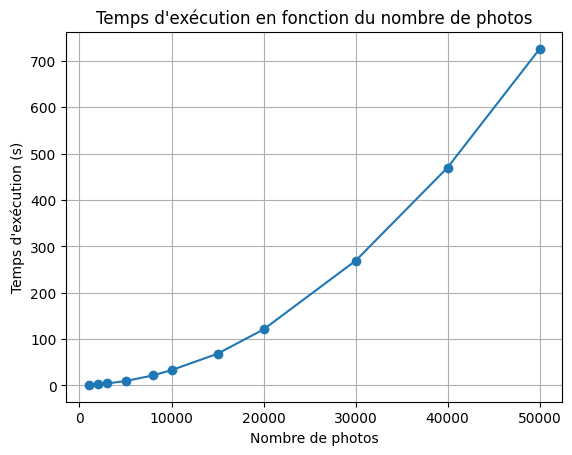

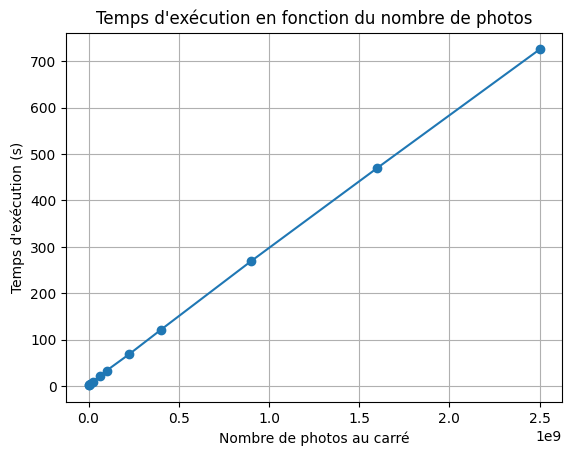

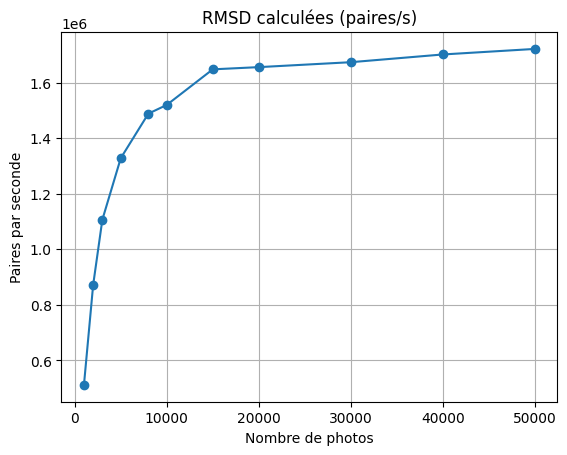

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Charger le fichier CSV
df = pd.read_csv("Times.csv")

# Adapter les noms de colonnes si besoin
df.columns = ["size", "time"]

# Calcul du nombre de paires et du débit
df["pairs"] = df["size"] * (df["size"] - 1) / 2
df["pairs_per_sec"] = df["pairs"] / df["time"]

# --- Plot 1 : Temps vs taille ---
plt.figure()
plt.plot(df["size"], df["time"], marker='o')
plt.xlabel("Nombre de photos")
plt.ylabel("Temps d'exécution (s)")
plt.title("Temps d'exécution en fonction du nombre de photos")
plt.grid()
plt.show()

# --- Plot 2 : Temps vs n² ---
plt.figure()
plt.plot(df["size"]**2, df["time"], marker='o')
plt.xlabel("Nombre de photos au carré")
plt.ylabel("Temps d'exécution (s)")
plt.title("Temps d'exécution en fonction du nombre de photos")
plt.grid()
plt.show()

# --- Plot 3 : Débit (pairs/s) ---
plt.figure()
plt.plot(df["size"], df["pairs_per_sec"], marker='o')
plt.xlabel("Nombre de photos")
plt.ylabel("Paires par seconde")
plt.title("RMSD calculées (paires/s)")
plt.grid()
plt.show()

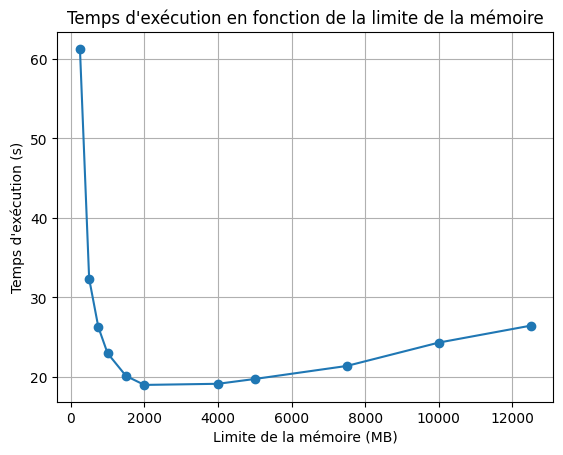

In [10]:
df = pd.read_csv("Limits.csv")
plt.plot(df["Limits"], df["Temps"], marker='o')
plt.xlabel("Limite de la mémoire (MB)")
plt.ylabel("Temps d'exécution (s)")
plt.title("Temps d'exécution en fonction de la limite de la mémoire")
plt.grid()
plt.show()

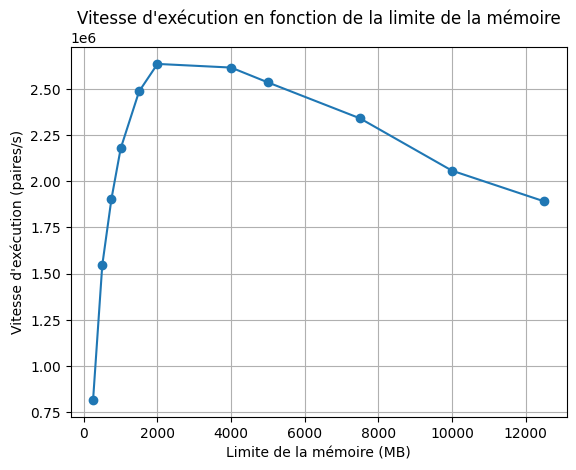

In [13]:
nb_pairs = 10000 * 9999 / 2

plt.plot(df["Limits"], nb_pairs/df["Temps"], marker='o')
plt.xlabel("Limite de la mémoire (MB)")
plt.ylabel("Vitesse d'exécution (paires/s)")
plt.title("Vitesse d'exécution en fonction de la limite de la mémoire")
plt.grid()
plt.show()

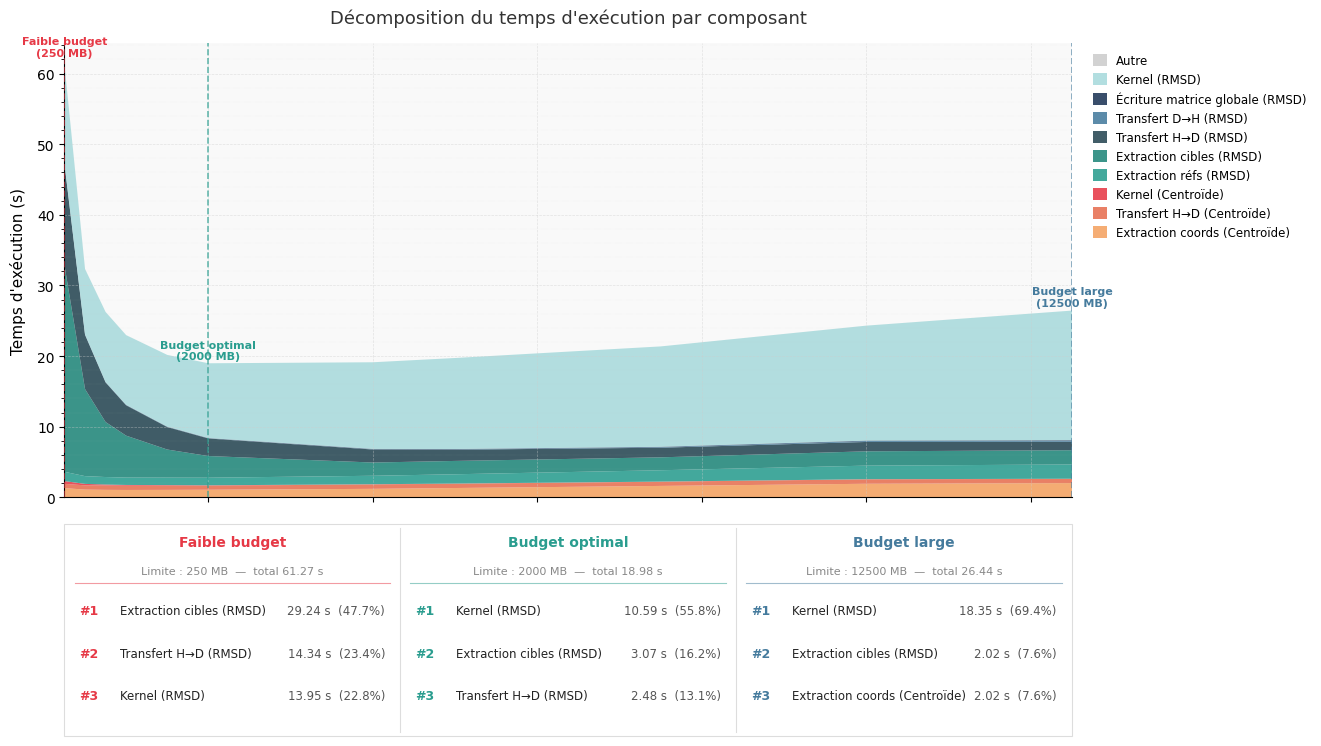

In [14]:
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker

# --- Chargement des données ---
detailed = pd.read_csv("LimitsDetailed.csv")
limits_df = pd.read_csv("Limits.csv")

detailed.columns = detailed.columns.str.strip()
limits_df.columns = limits_df.columns.str.strip()

detailed = detailed.set_index("Limits")
limits_df = limits_df.set_index("Limits")

detailed["Autre"] = limits_df["Temps"] - detailed.sum(axis=1)
detailed = detailed.clip(lower=0)

rename = {
    "Extraction des coordonnées (Centroid)":            "Extraction coords (Centroïde)",
    "Transfert H-D (Centroid)":                         "Transfert H→D (Centroïde)",
    "Kernel (Centroid)":                                "Kernel (Centroïde)",
    "Extraction des coordonnées des références (RMSD)": "Extraction réfs (RMSD)",
    "Extraction des coordonnées des cibles (RMSD)":     "Extraction cibles (RMSD)",
    "Transfert H-D (RMSD)":                             "Transfert H→D (RMSD)",
    "Transfert D-H (RMSD)":                             "Transfert D→H (RMSD)",
    "Ecriture dans la matrice globale (RMSD)":          "Écriture matrice globale (RMSD)",
    "Kernel (RMSD)":                                    "Kernel (RMSD)",
    "Autre":                                            "Autre",
}
detailed = detailed.rename(columns=rename)

colors = [
    "#f4a261",
    "#e76f51",
    "#e63946",
    "#2a9d8f",
    "#21867a",
    "#264653",
    "#457b9d",
    "#1d3557",
    "#a8dadc",
    "#cccccc",
]

x    = detailed.index.values
cols = list(rename.values())
data = [detailed[c].values for c in cols]

xi_first  = x[0]
xi_last   = x[-1]
xi_minsum = detailed.sum(axis=1).idxmin()

seen = set()
key_points = []
for xi, title in [(xi_first, "Faible budget"), (xi_minsum, "Budget optimal"), (xi_last, "Budget large")]:
    if xi not in seen:
        key_points.append((xi, title))
        seen.add(xi)

fig = plt.figure(figsize=(13, 9))
fig.patch.set_facecolor("#ffffff")
gs  = GridSpec(2, 1, figure=fig, height_ratios=[3, 1.4], hspace=0.08)

ax = fig.add_subplot(gs[0])
ax.set_facecolor("#f9f9f9")
ax.stackplot(x, data, labels=cols, colors=colors, alpha=0.88)

color_map = {
    "Faible budget":   "#e63946",
    "Budget optimal":  "#2a9d8f",
    "Budget large":    "#457b9d",
}

for xi, title in key_points:
    total = detailed.loc[xi].sum()
    ax.axvline(xi, color=color_map[title], lw=1.2, linestyle="--", zorder=3, alpha=0.7)
    ax.text(xi, total * 1.015, f"{title}\n({xi} MB)",
            ha="center", va="bottom", fontsize=8,
            color=color_map[title], fontweight="bold")

ax.set_ylabel("Temps d'exécution (s)", fontsize=11, labelpad=8)
ax.set_title("Décomposition du temps d'exécution par composant",
             fontsize=13, fontweight="500", pad=14, color="#333333")
ax.set_xlim(x[0], x[-1])
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(which="major", linestyle="--", linewidth=0.5, alpha=0.5, color="#cccccc")
ax.grid(which="minor", linestyle=":",  linewidth=0.3, alpha=0.3, color="#cccccc")
ax.tick_params(labelbottom=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

handles, labels_leg = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels_leg[::-1],
          loc="upper left", bbox_to_anchor=(1.01, 1),
          fontsize=8.5, frameon=False, handlelength=1.2, handleheight=1.2)

# --- Tableau ---
ax_tbl = fig.add_subplot(gs[1])
ax_tbl.set_xlim(0, 1)
ax_tbl.set_ylim(0, 1)
ax_tbl.axis("off")

n_cols = len(key_points)
col_w  = 1.0 / n_cols

for col_idx, (xi, title) in enumerate(key_points):
    col_values = {c: detailed.loc[xi, c] for c in cols}
    total      = sum(col_values.values())
    top3       = sorted(col_values.items(), key=lambda kv: kv[1], reverse=True)[:3]

    accent   = color_map[title]
    x_left   = col_idx * col_w
    x_center = x_left + col_w / 2

    # En-tête
    ax_tbl.text(x_center, 0.95, title,
                transform=ax_tbl.transAxes,
                ha="center", va="top",
                fontsize=10, fontweight="bold", color=accent)
    ax_tbl.text(x_center, 0.80, f"Limite : {xi} MB  —  total {total:.2f} s",
                transform=ax_tbl.transAxes,
                ha="center", va="top",
                fontsize=8, color="#888888")

    # Ligne de séparation sous l'en-tête
    line_y = 0.72
    ax_tbl.plot(
        [x_left + 0.01, x_left + col_w - 0.01],
        [line_y, line_y],
        color=accent, lw=0.8, alpha=0.5,
        transform=ax_tbl.transAxes, clip_on=False
    )

    # Top 3 lignes
    row_tops = [0.62, 0.42, 0.22]
    for rank, ((comp, val), row_y) in enumerate(zip(top3, row_tops)):
        pct = 100 * val / total
        ax_tbl.text(x_left + 0.015, row_y, f"#{rank+1}",
                    transform=ax_tbl.transAxes,
                    ha="left", va="top",
                    fontsize=9, fontweight="bold", color=accent)
        ax_tbl.text(x_left + 0.055, row_y, comp,
                    transform=ax_tbl.transAxes,
                    ha="left", va="top",
                    fontsize=8.5, color="#222222")
        ax_tbl.text(x_left + col_w - 0.015, row_y,
                    f"{val:.2f} s  ({pct:.1f}%)",
                    transform=ax_tbl.transAxes,
                    ha="right", va="top",
                    fontsize=8.5, color="#555555")

    # Séparateur vertical entre colonnes
    if col_idx < n_cols - 1:
        sep_x = x_left + col_w
        ax_tbl.plot(
            [sep_x, sep_x], [0.02, 0.98],
            color="#dddddd", lw=0.8,
            transform=ax_tbl.transAxes, clip_on=False
        )

# Bordure extérieure du tableau
rect = plt.Rectangle((0, 0), 1, 1, fill=False,
                      edgecolor="#dddddd", lw=0.8,
                      transform=ax_tbl.transAxes, clip_on=False)
ax_tbl.add_patch(rect)

plt.show()